# 01. Load, QC, and merge TH1/TH2 retina scRNA-seq data

This notebook loads the two 10x matrices, computes basic QC metrics, applies transparent filtering thresholds, and saves a merged `.h5ad` object for downstream clustering and differential expression.

Biological framing:
- `TH1`: Chx10Cre control
- `TH2`: Chx10Cre/Insm1 knockout

Immediate goal:
- produce a clean merged object for later cell type annotation and DE in rod/cone cells and Muller glia

## Imports

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("whitegrid")

/var/folders/bw/h94700p51374zgrbzwg8hrbh0000gn/T/ipykernel_42712/828049319.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)


## Resolve project paths

This notebook is written to work from inside the repo without hard-coded absolute paths.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "samples.csv").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing config/samples.csv")


cwd = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(cwd)
SAMPLES_CSV = PROJECT_ROOT / "config" / "samples.csv"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
RESULTS_QC_DIR = PROJECT_ROOT / "results" / "qc"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_QC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Sample sheet: {SAMPLES_CSV}")

Project root: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2
Sample sheet: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/config/samples.csv


## Load sample sheet

In [3]:
samples = pd.read_csv(SAMPLES_CSV)
samples

,sample_id,condition,raw_matrix_dir
0,TH1,TH1,data/raw/10x/TH1
1,TH2,TH2,data/raw/10x/TH2


In [4]:
condition_map = {
    "TH1": "Control",
    "TH2": "Insm1_KO",
}

samples["biological_condition"] = samples["sample_id"].map(condition_map).fillna(samples["condition"])
samples

,sample_id,condition,raw_matrix_dir,biological_condition
0,TH1,TH1,data/raw/10x/TH1,Control
1,TH2,TH2,data/raw/10x/TH2,Insm1_KO


## Read 10x matrices

In [5]:
adatas = []

for row in samples.itertuples(index=False):
    matrix_dir = PROJECT_ROOT / row.raw_matrix_dir
    adata = sc.read_10x_mtx(matrix_dir, var_names="gene_symbols")
    adata.var_names_make_unique()
    adata.obs_names_make_unique()
    adata.obs["sample_id"] = row.sample_id
    adata.obs["condition"] = row.biological_condition
    adata.obs["raw_matrix_dir"] = str(matrix_dir)
    adatas.append(adata)
    print(f"{row.sample_id}: {adata.n_obs} cells x {adata.n_vars} genes")


TH1: 1524244 cells x 32286 genes
TH2: 2056744 cells x 32286 genes


## Compute QC metrics

In [6]:
for adata in adatas:
    adata.var["mt"] = adata.var_names.str.lower().str.startswith("mt-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)

qc_summary = pd.concat(
    [
        adata.obs.assign(sample_id=adata.obs["sample_id"].iloc[0])[ [
            "sample_id", "total_counts", "n_genes_by_counts", "pct_counts_mt"
        ] ]
        for adata in adatas
    ],
    ignore_index=True,
)
qc_summary.groupby("sample_id").agg(["median", "mean"]).round(2)

total_counts            n_genes_by_counts        pct_counts_mt      
                median       mean            median   mean        median  mean
sample_id                                                                     
TH1                1.0  63.939999               1.0  39.62           0.0  8.06
TH2                1.0  79.169998               1.0  45.52           0.0  9.29

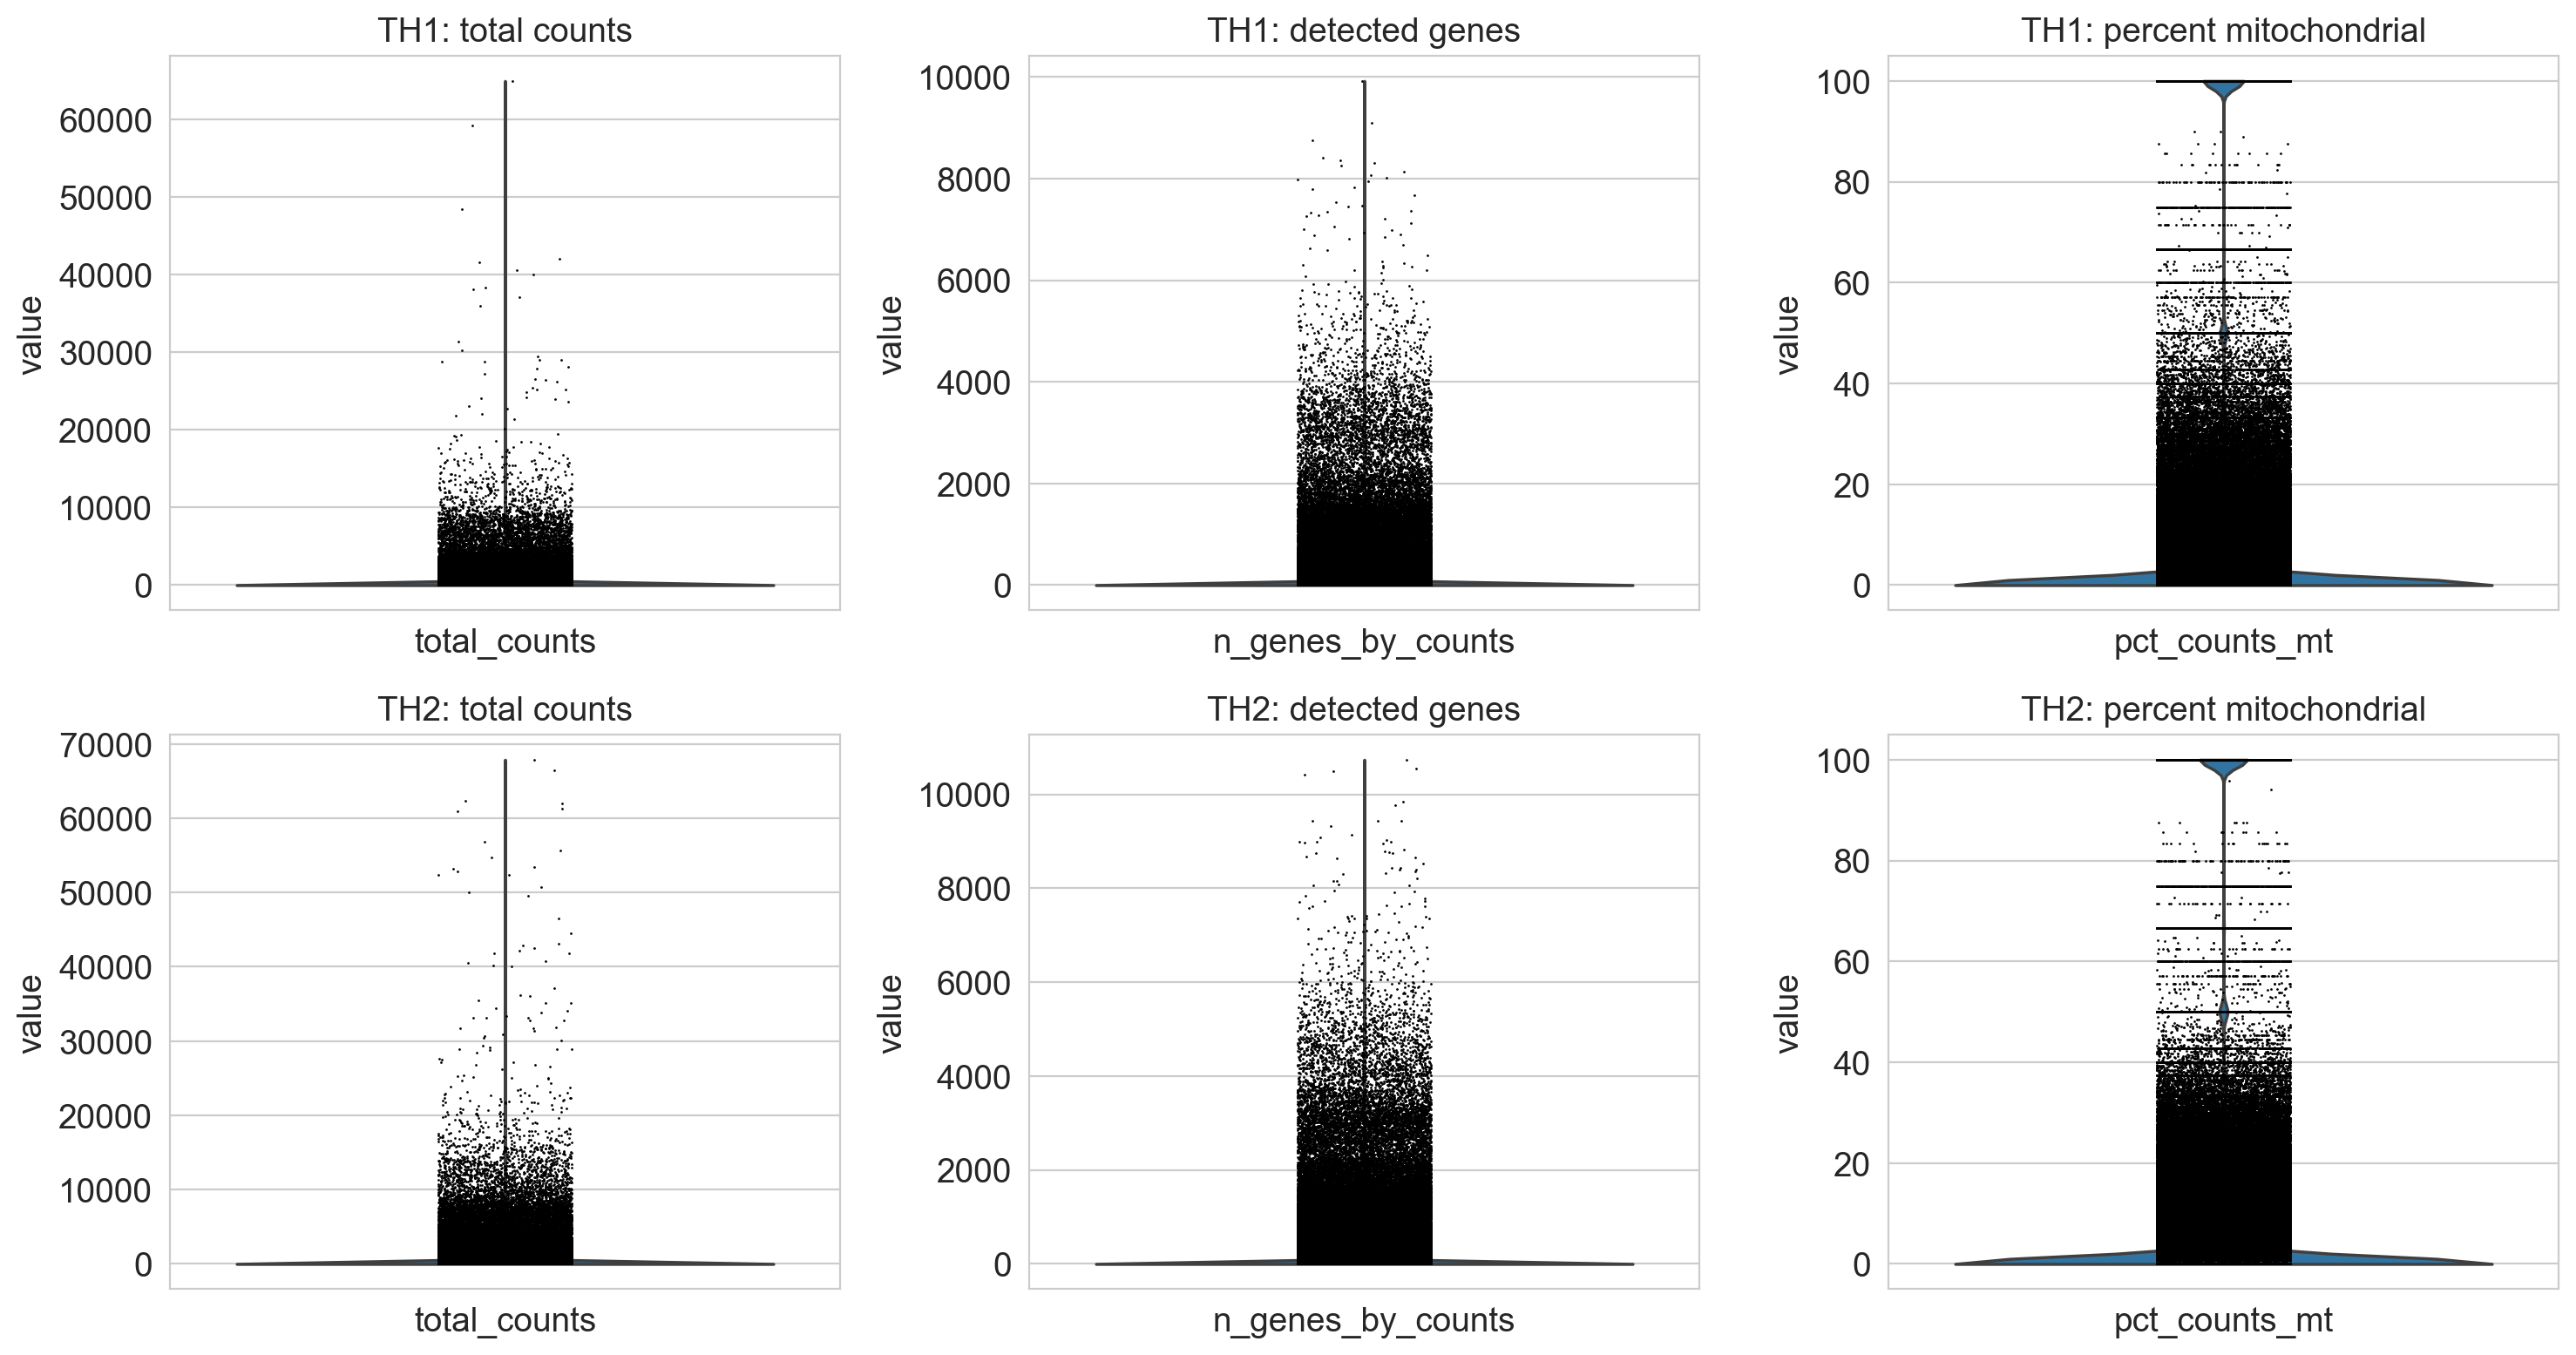

In [7]:
fig, axes = plt.subplots(len(adatas), 3, figsize=(15, 4 * len(adatas)))
if len(adatas) == 1:
    axes = [axes]

for i, adata in enumerate(adatas):
    sample_id = adata.obs["sample_id"].iloc[0]
    sc.pl.violin(adata, "total_counts", ax=axes[i][0], show=False)
    sc.pl.violin(adata, "n_genes_by_counts", ax=axes[i][1], show=False)
    sc.pl.violin(adata, "pct_counts_mt", ax=axes[i][2], show=False)
    axes[i][0].set_title(f"{sample_id}: total counts")
    axes[i][1].set_title(f"{sample_id}: detected genes")
    axes[i][2].set_title(f"{sample_id}: percent mitochondrial")

plt.tight_layout()
plt.show()

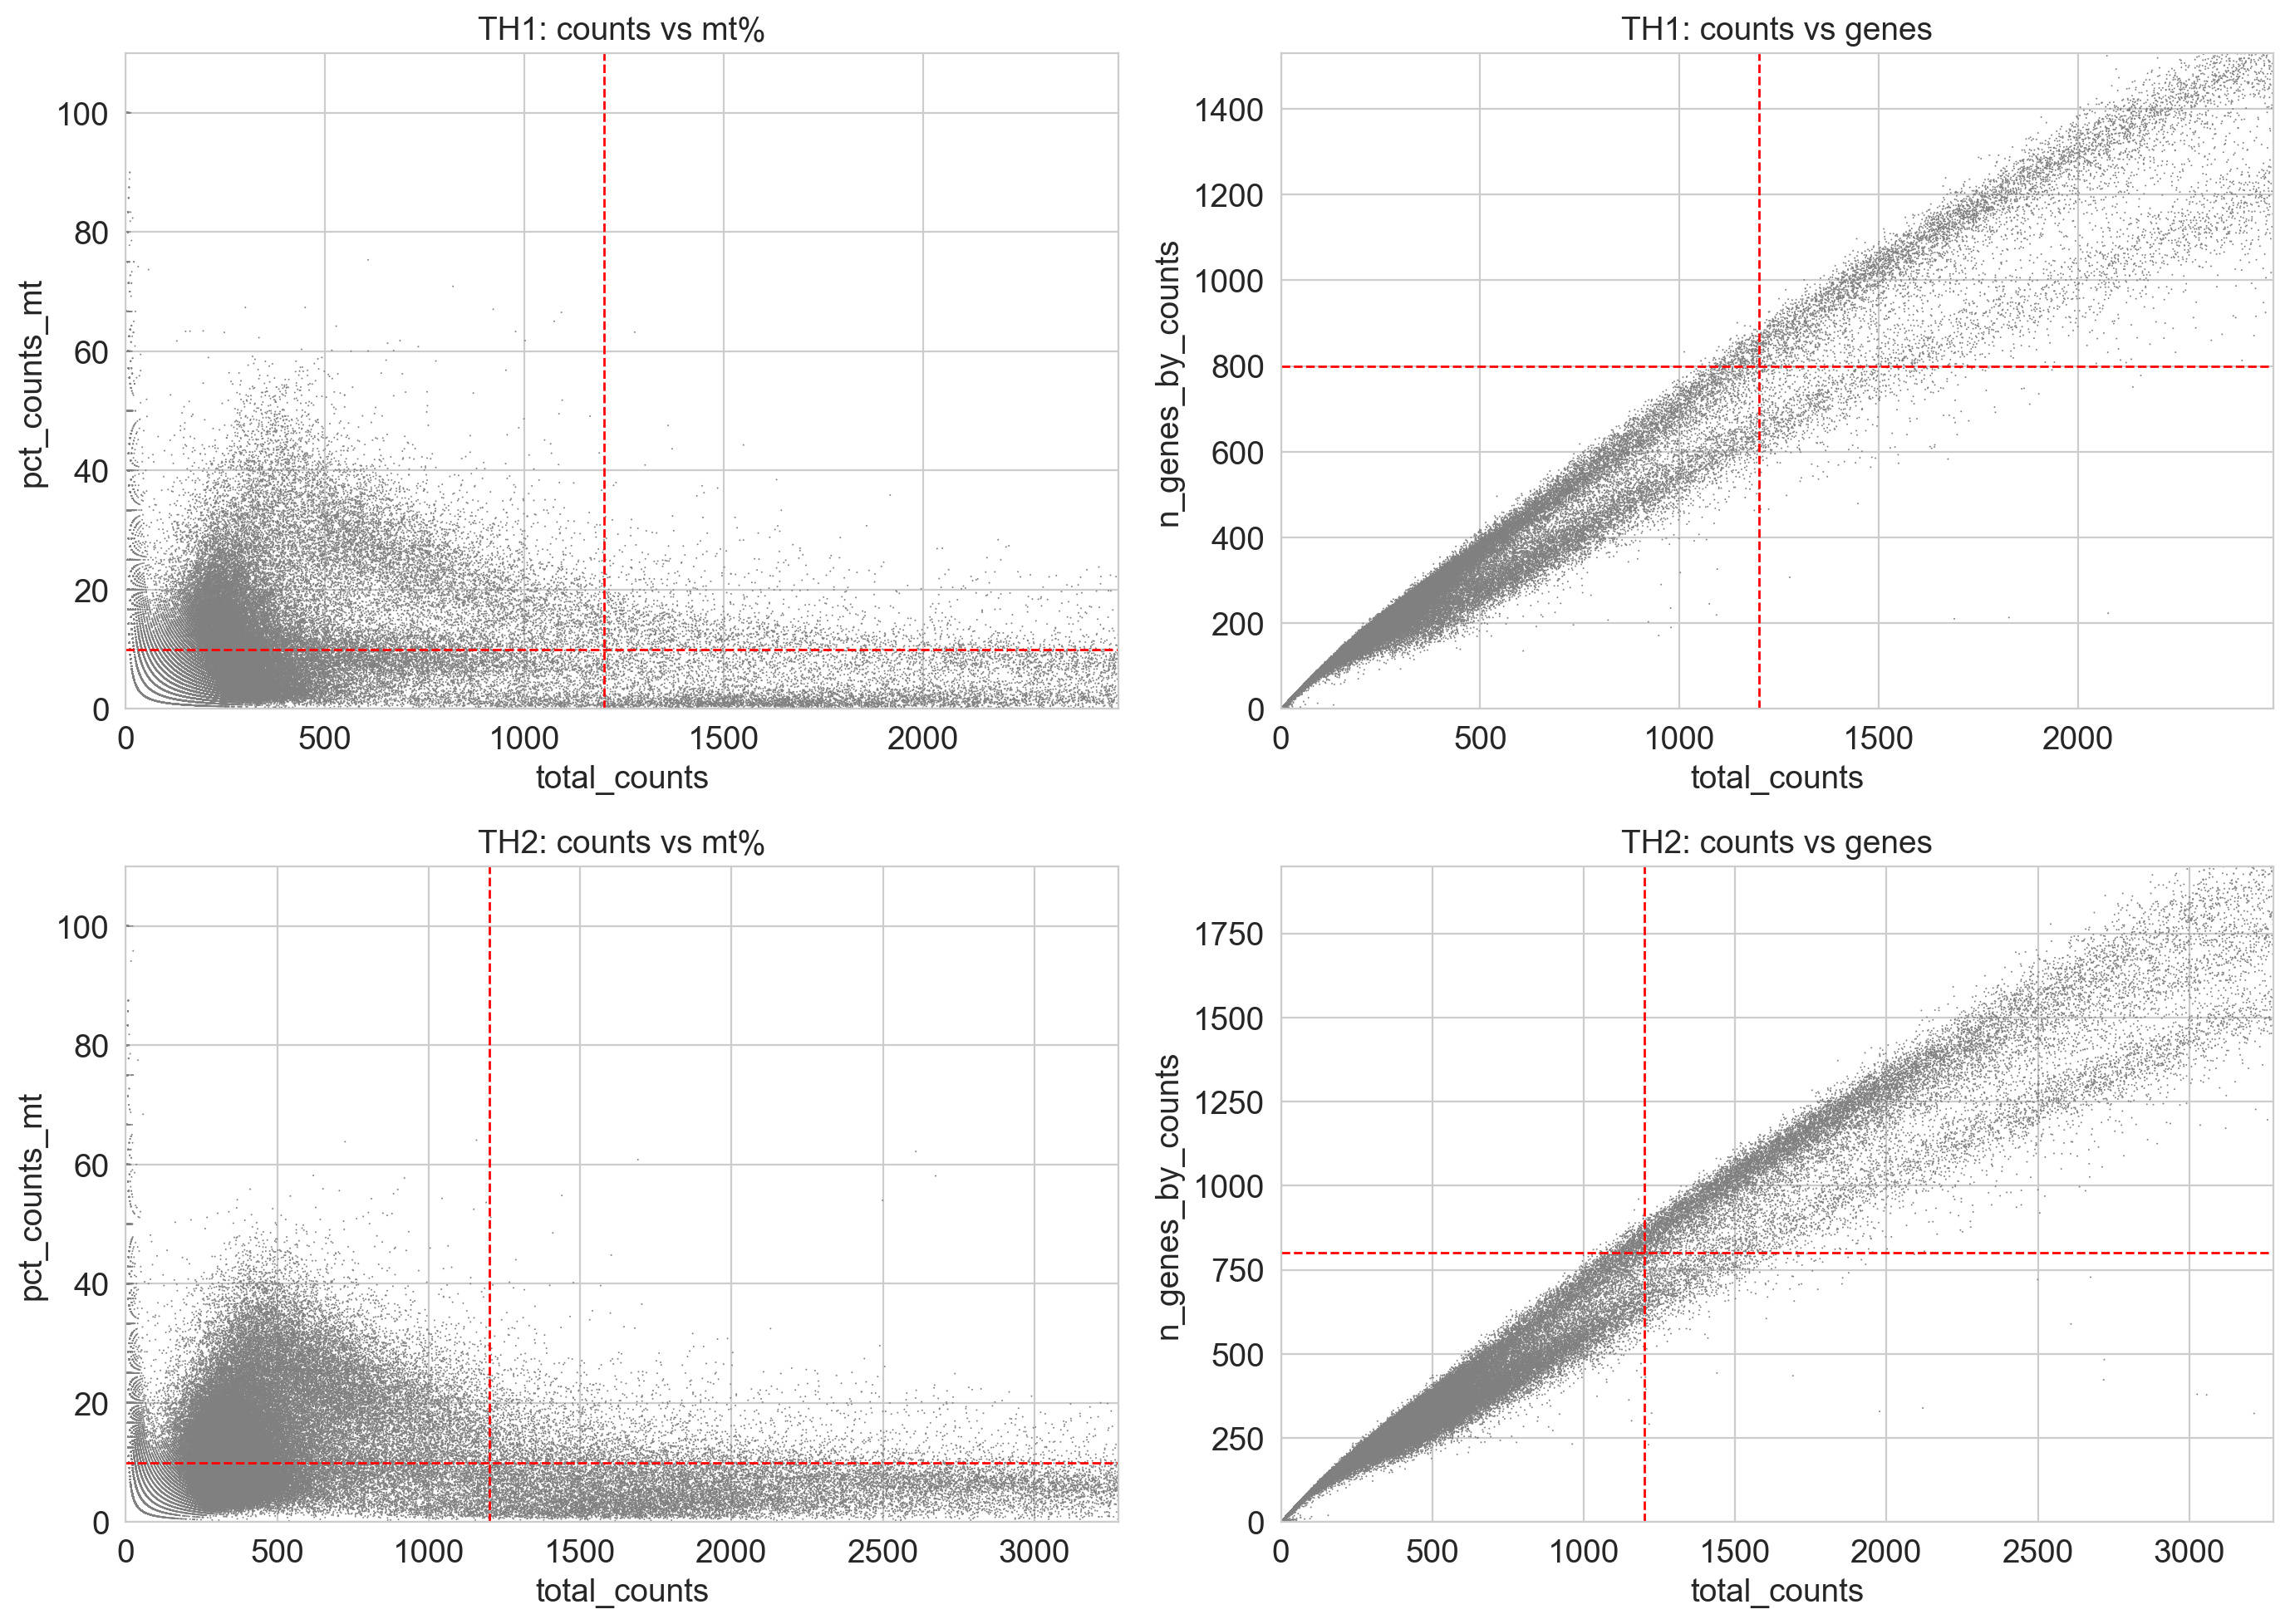

In [9]:
fig, axes = plt.subplots(len(adatas), 2, figsize=(14, 5 * len(adatas)))

if len(adatas) == 1:
    axes = [axes]

for i, adata in enumerate(adatas):
    sample_id = adata.obs["sample_id"].iloc[0]

    total_counts_max = adata.obs["total_counts"].quantile(0.995)
    mt_pct_max = adata.obs["pct_counts_mt"].quantile(0.995)
    n_genes_max = adata.obs["n_genes_by_counts"].quantile(0.995)

    sc.pl.scatter(
        adata,
        x="total_counts",
        y="pct_counts_mt",
        ax=axes[i][0],
        show=False,
        size=2,
    )
    axes[i][0].axvline(1200, color="red", linestyle="--", linewidth=1)
    axes[i][0].axvline(30000, color="red", linestyle="--", linewidth=1)
    axes[i][0].axhline(10, color="red", linestyle="--", linewidth=1)
    axes[i][0].set_title(f"{sample_id}: counts vs mt%")
    axes[i][0].set_xlim(0, total_counts_max)
    axes[i][0].set_ylim(0, max(mt_pct_max, 10) * 1.1)

    sc.pl.scatter(
        adata,
        x="total_counts",
        y="n_genes_by_counts",
        ax=axes[i][1],
        show=False,
        size=2,
    )
    axes[i][1].axvline(1200, color="red", linestyle="--", linewidth=1)
    axes[i][1].axvline(30000, color="red", linestyle="--", linewidth=1)
    axes[i][1].axhline(800, color="red", linestyle="--", linewidth=1)
    axes[i][1].axhline(8000, color="red", linestyle="--", linewidth=1)
    axes[i][1].set_title(f"{sample_id}: counts vs genes")
    axes[i][1].set_xlim(0, total_counts_max)
    axes[i][1].set_ylim(0, max(n_genes_max, 800) * 1.1)

plt.tight_layout()
plt.show()


## Apply initial filtering

These thresholds are matched to the reference notebook so you can compare results directly.

Reference thresholds:
- minimum genes per cell: `800`
- maximum genes per cell: `8000`
- minimum UMI counts per cell: `1200`
- maximum UMI counts per cell: `30000`
- maximum mitochondrial fraction: `10%`

In [10]:
FILTERS = {
    "min_genes": 800,
    "max_genes": 8000,
    "min_counts": 1200,
    "max_counts": 30000,
    "max_mt_pct": 10,
}
FILTERS

{'min_genes': 800,
 'max_genes': 8000,
 'min_counts': 1200,
 'max_counts': 30000,
 'max_mt_pct': 10}

In [11]:
filtered_adatas = []
filter_stats = []

for adata in adatas:
    keep = (
        (adata.obs["n_genes_by_counts"] >= FILTERS["min_genes"])
        & (adata.obs["n_genes_by_counts"] <= FILTERS["max_genes"])
        & (adata.obs["total_counts"] >= FILTERS["min_counts"])
        & (adata.obs["total_counts"] <= FILTERS["max_counts"])
        & (adata.obs["pct_counts_mt"] < FILTERS["max_mt_pct"])
    )
    filtered = adata[keep].copy()
    sample_id = adata.obs["sample_id"].iloc[0]
    filtered_adatas.append(filtered)
    filter_stats.append({
        "sample_id": sample_id,
        "cells_before": adata.n_obs,
        "cells_after": filtered.n_obs,
        "cells_removed": adata.n_obs - filtered.n_obs,
        "fraction_retained": round(filtered.n_obs / adata.n_obs, 4),
    })

filter_stats_df = pd.DataFrame(filter_stats)
filter_stats_df

,sample_id,cells_before,cells_after,cells_removed,fraction_retained
0,TH1,1524244,13515,1510729,0.0089
1,TH2,2056744,24214,2032530,0.0118


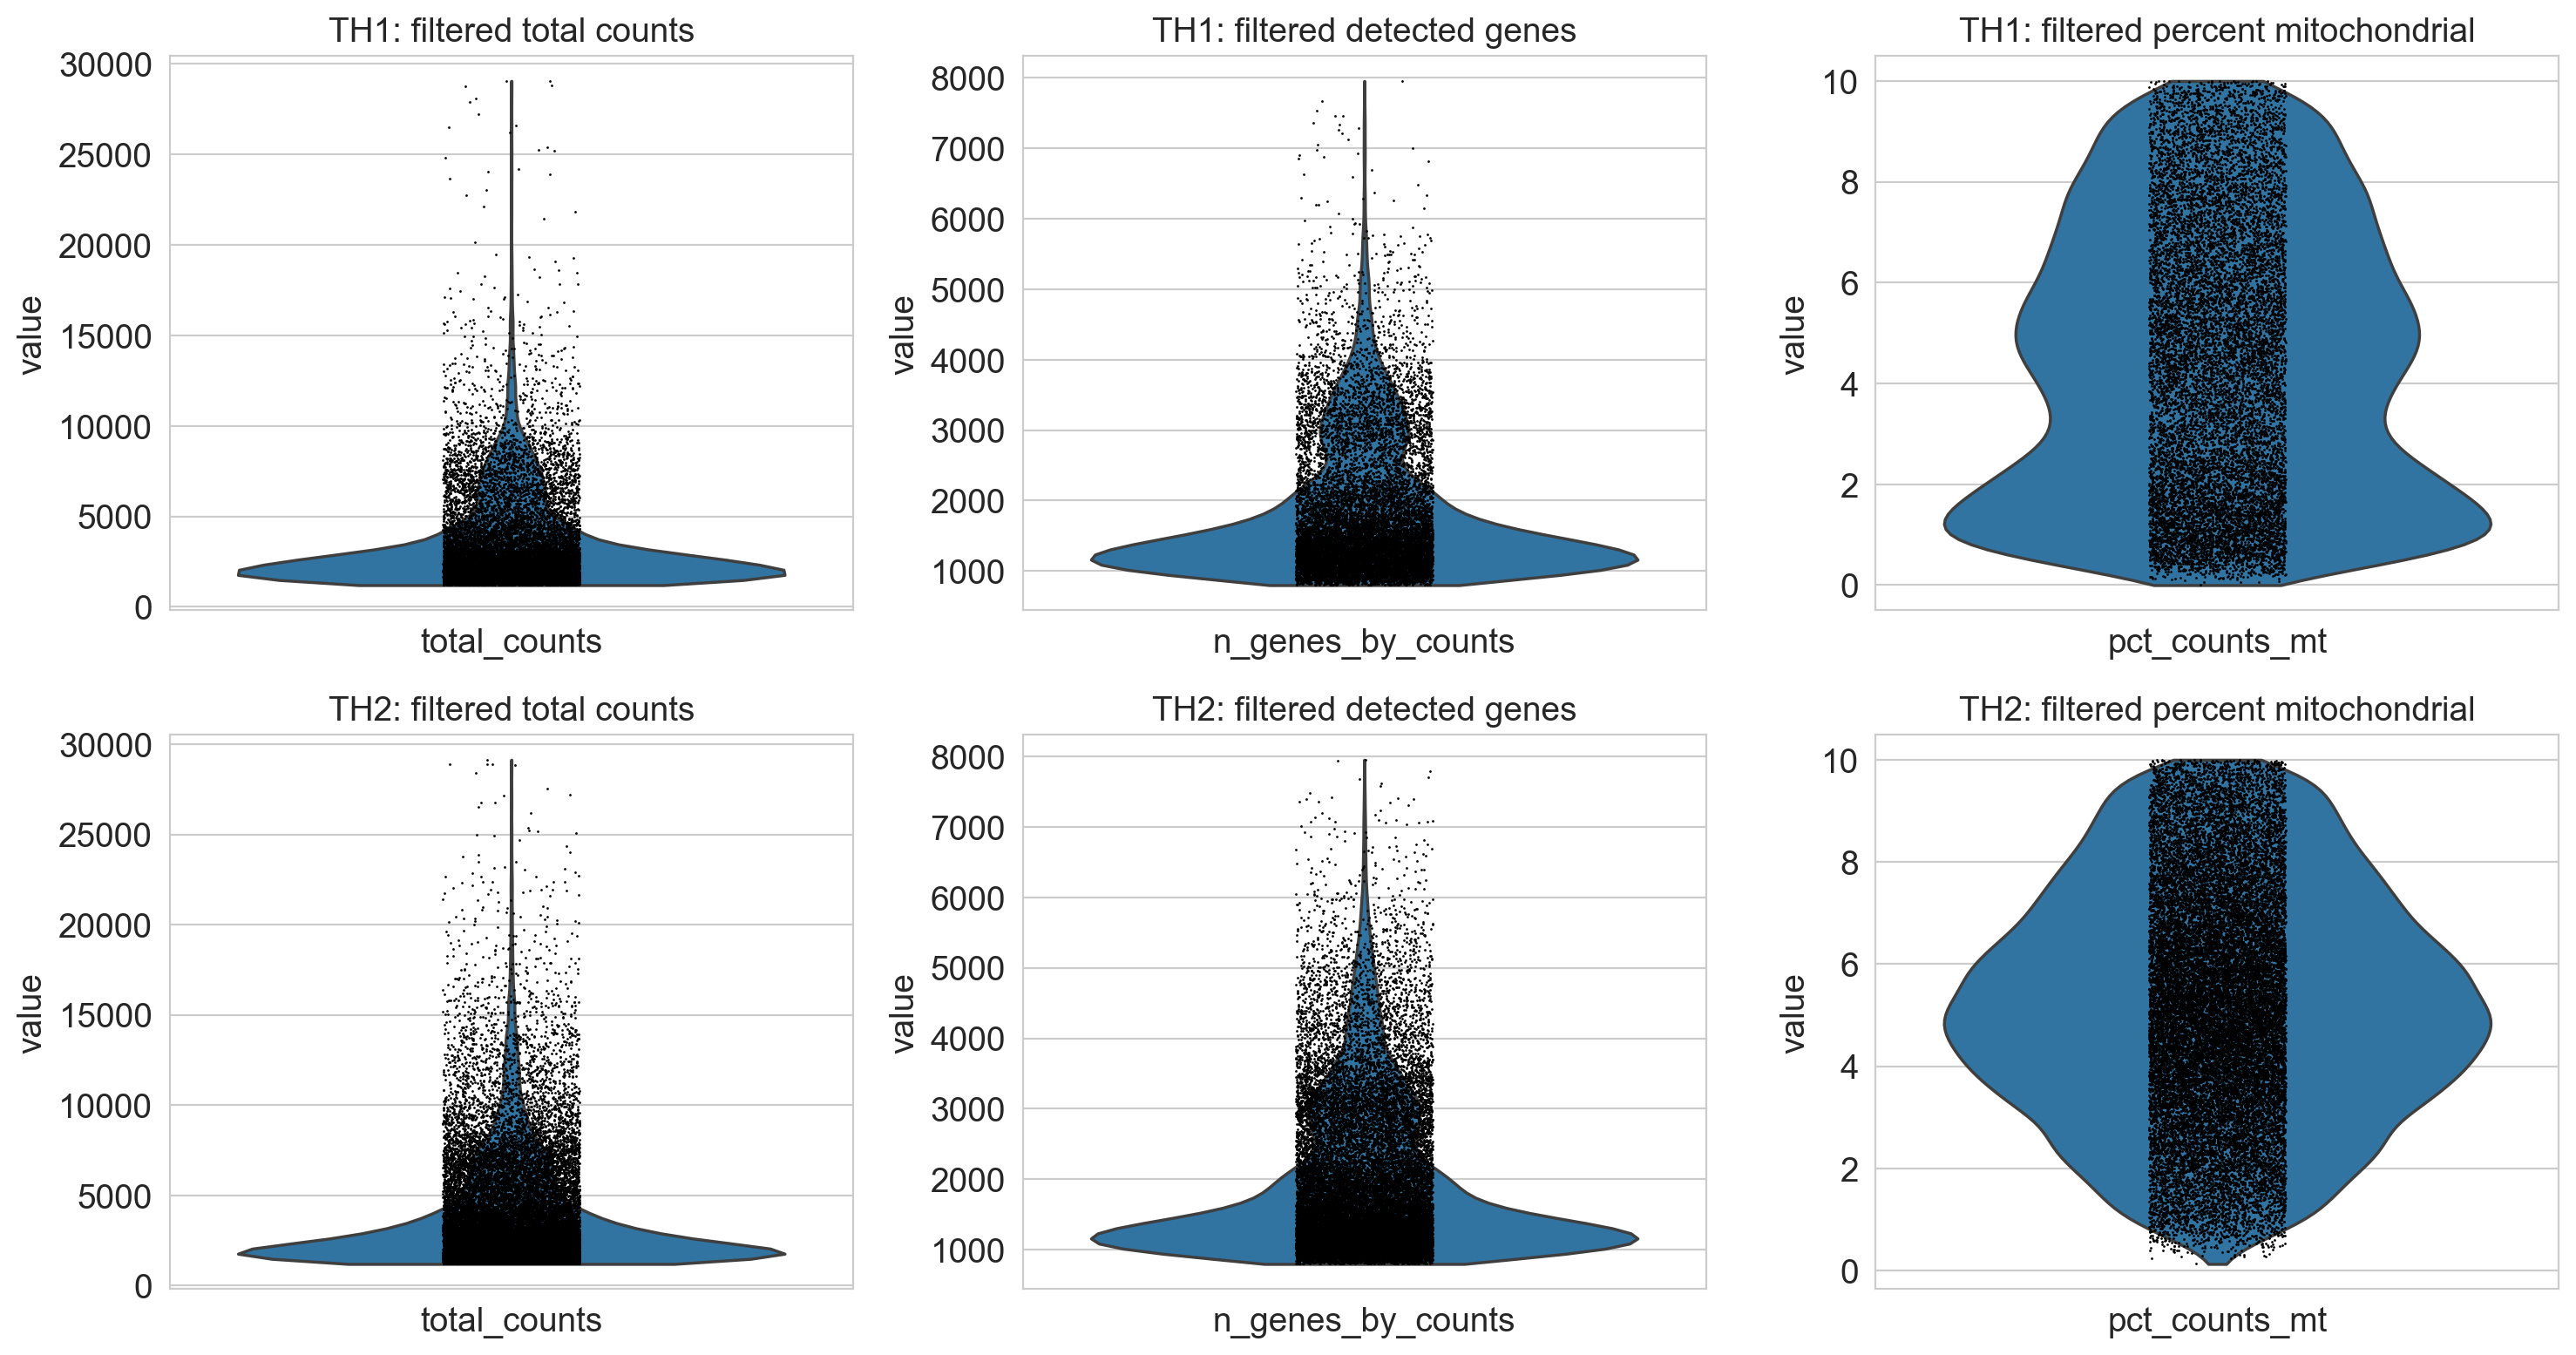

In [12]:
fig, axes = plt.subplots(len(filtered_adatas), 3, figsize=(15, 4 * len(filtered_adatas)))
if len(filtered_adatas) == 1:
    axes = [axes]

for i, adata in enumerate(filtered_adatas):
    sample_id = adata.obs["sample_id"].iloc[0]
    sc.pl.violin(adata, "total_counts", ax=axes[i][0], show=False)
    sc.pl.violin(adata, "n_genes_by_counts", ax=axes[i][1], show=False)
    sc.pl.violin(adata, "pct_counts_mt", ax=axes[i][2], show=False)
    axes[i][0].set_title(f"{sample_id}: filtered total counts")
    axes[i][1].set_title(f"{sample_id}: filtered detected genes")
    axes[i][2].set_title(f"{sample_id}: filtered percent mitochondrial")

plt.tight_layout()
plt.show()

## Merge filtered samples

In [13]:
adata_merged = ad.concat(
    filtered_adatas,
    label="sample_id",
    keys=[adata.obs["sample_id"].iloc[0] for adata in filtered_adatas],
    join="outer",
    merge="same",
    index_unique="-",
)

adata_merged.obs["condition"] = adata_merged.obs["condition"].astype("category")
adata_merged.obs["sample_id"] = adata_merged.obs["sample_id"].astype("category")
adata_merged.layers["counts"] = adata_merged.X.copy()
adata_merged

AnnData object with n_obs × n_vars = 37729 × 32286
    obs: 'sample_id', 'condition', 'raw_matrix_dir', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt'
    layers: 'counts'

## Save outputs for downstream notebooks

In [14]:
filter_stats_path = RESULTS_QC_DIR / "01_filter_summary.csv"
merged_path = INTERIM_DIR / "01_qc_merged.h5ad"

filter_stats_df.to_csv(filter_stats_path, index=False)
adata_merged.write(merged_path)

print(f"Saved filter summary: {filter_stats_path}")
print(f"Saved merged AnnData: {merged_path}")

Saved filter summary: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/qc/01_filter_summary.csv
Saved merged AnnData: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/data/interim/01_qc_merged.h5ad


## Notes for review

Before moving to clustering and cell type annotation, review:
- whether the QC thresholds are too strict for aged retina photoreceptors
- whether mitochondrial fraction should be tightened or relaxed
- whether an upper total-count threshold should be added before doublet detection

The next notebook should handle:
- normalization
- HVG selection
- PCA / neighbors / UMAP
- Leiden clustering
- marker-based annotation of major retinal cell types